In [8]:
from tensorflow.keras import Input,layers

inputs = Input(shape=(224,224,3))
print(inputs.shape)
print(inputs.dtype)

(None, 224, 224, 3)
float32


In [9]:
# layer 2
x = layers.Conv2D(32 ,(3,3), activation='relu')(inputs)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1,activation="sigmoid")(x)

In [10]:
#create model
from tensorflow.keras import Model
model = Model(inputs=inputs,outputs=outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 394272)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │    50,466,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,467,969 (192.52 MB)

 Trainable params: 50,467,969 (192.52 MB)

 Non-trainable params: 0 (0.00 B)

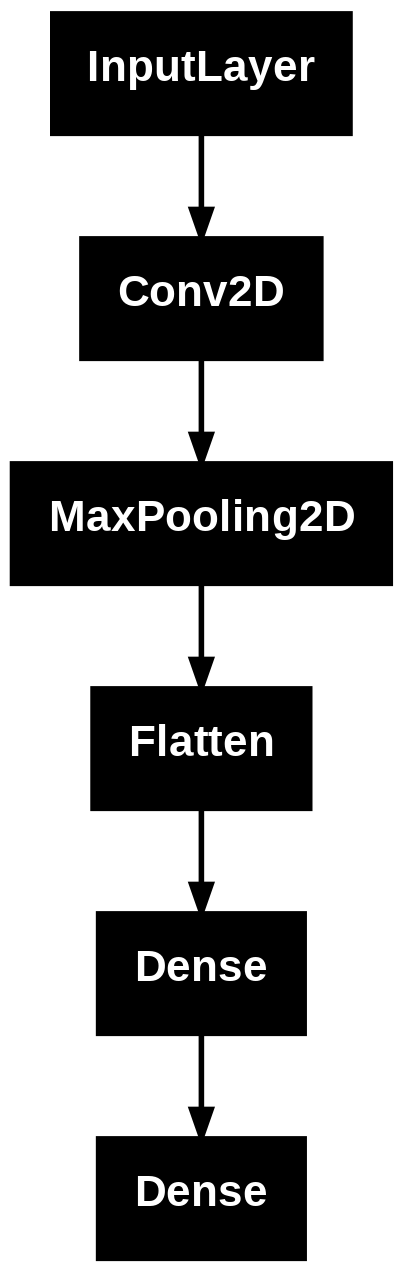

In [11]:
from keras.utils import plot_model

# Fix: Pass the model object directly and show shapes
plot_model(model)

In [12]:
# multiple input and multiple output
image_input = Input(shape=(224,224,3), name = "image_input")
x = layers.Conv2D(32, (3,3), activation='relu')(image_input)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)  # image branch ends here

meta_input = Input(shape=(3,), name='meta_input')
y = layers.Dense(16, activation='relu')(meta_input) # meta databranch

merged = layers.Concatenate()([x,y])
z = layers.Dense(1,activation='relu')(merged)
output = layers.Dense(1,activation='sigmoid', name='output')(z)

model = Model(
    inputs = [image_input, meta_input],
    outputs = output
)

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 222, 222,  │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 111, 111,  │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 394272)    │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_input          │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │ 25,233,472 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │         64 │ meta_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 80)        │          0 │ dense_9[0][0],    │
│ (Concatenate)       │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │         81 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │          2 │ dense_11[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,234,515 (96.26 MB)

 Trainable params: 25,234,515 (96.26 MB)

 Non-trainable params: 0 (0.00 B)

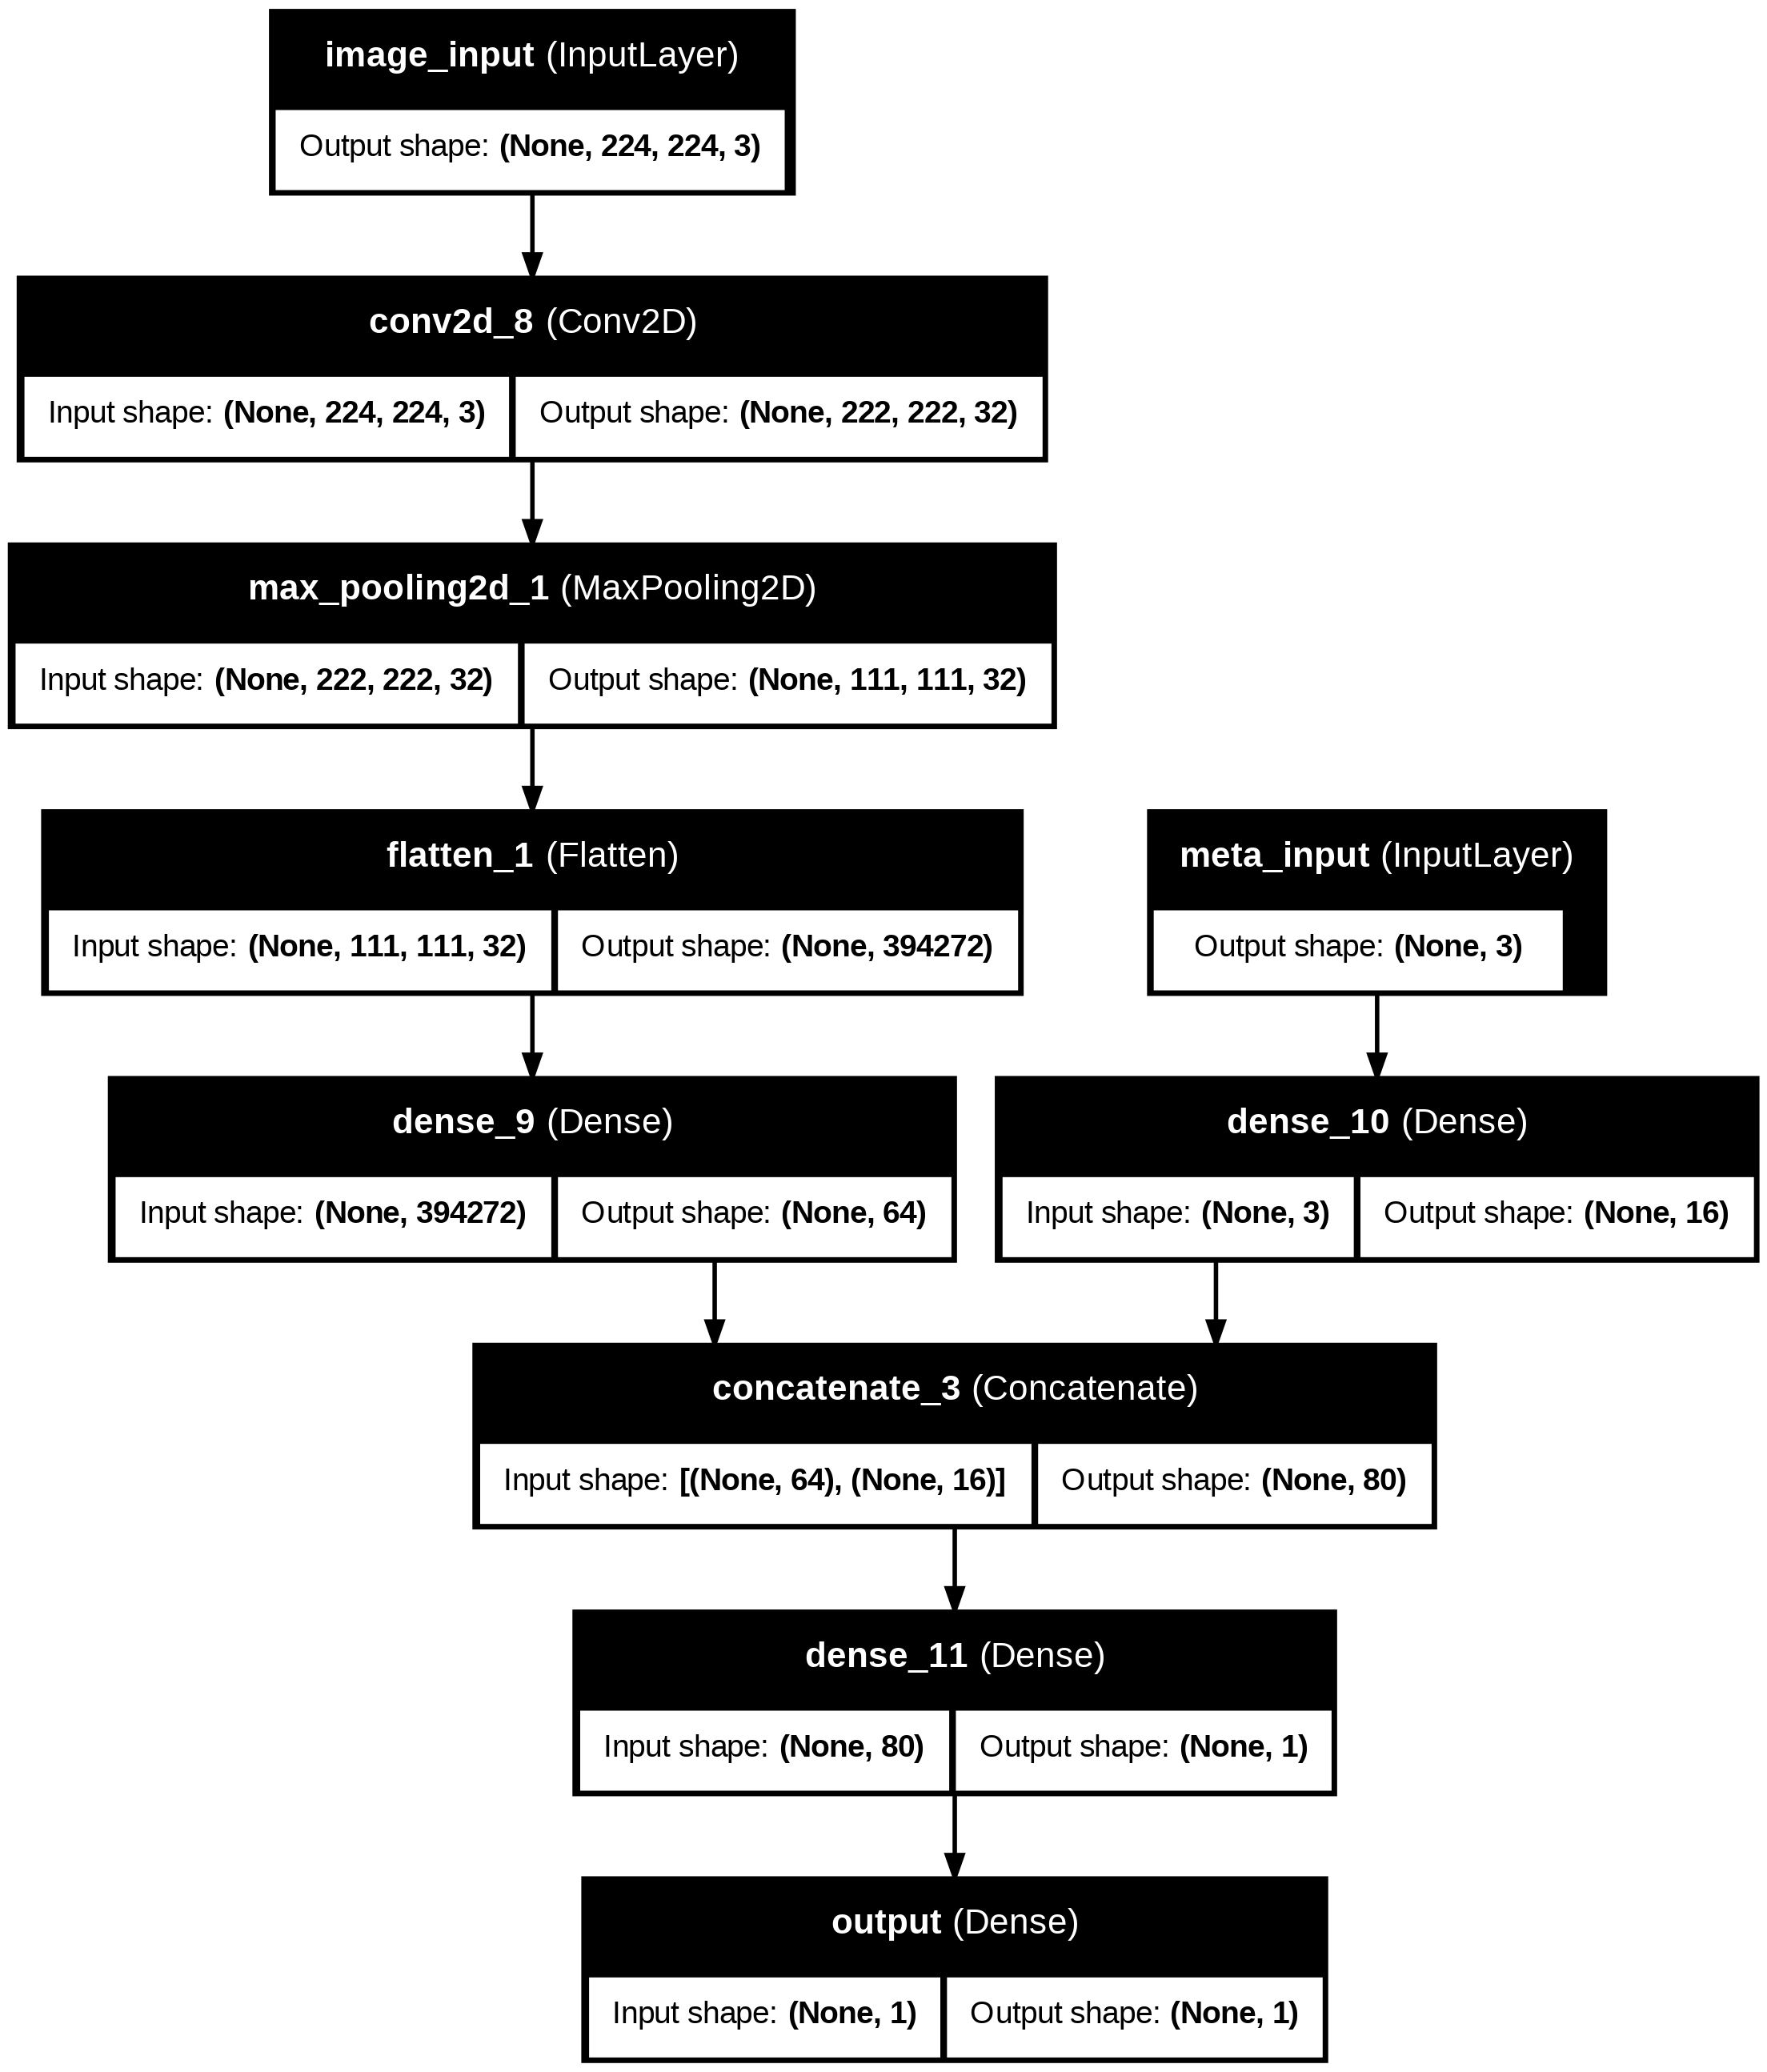

In [13]:
from keras.utils import plot_model
import IPython.display as display

# Save the model plot to a file
plot_file = 'model_plot.png'
plot_model(model, to_file=plot_file, show_shapes=True, show_layer_names=True)

# Display the image with a reduced width
display.Image(filename=plot_file, width=500)

In [14]:
# single input and multiple output
input = Input(shape=(224,224,3), name = "image_input")
x = layers.Conv2D(32,(3,3), activation = 'relu')(input)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)
shared = layers.Dense(128, activation='relu')(x)

class_out = layers.Dense(64, activation='relu')(shared)
class_out = layers.Dense(1,activation='sigmoid', name='class_output')(class_out)

bbox_out = layers.Dense(64, activation='relu')(shared)
bbox_out = layers.Dense(4, activation='linear', name='bbox_output')(bbox_out)

model = Model(inputs = input,
              outputs = [class_out, bbox_out])


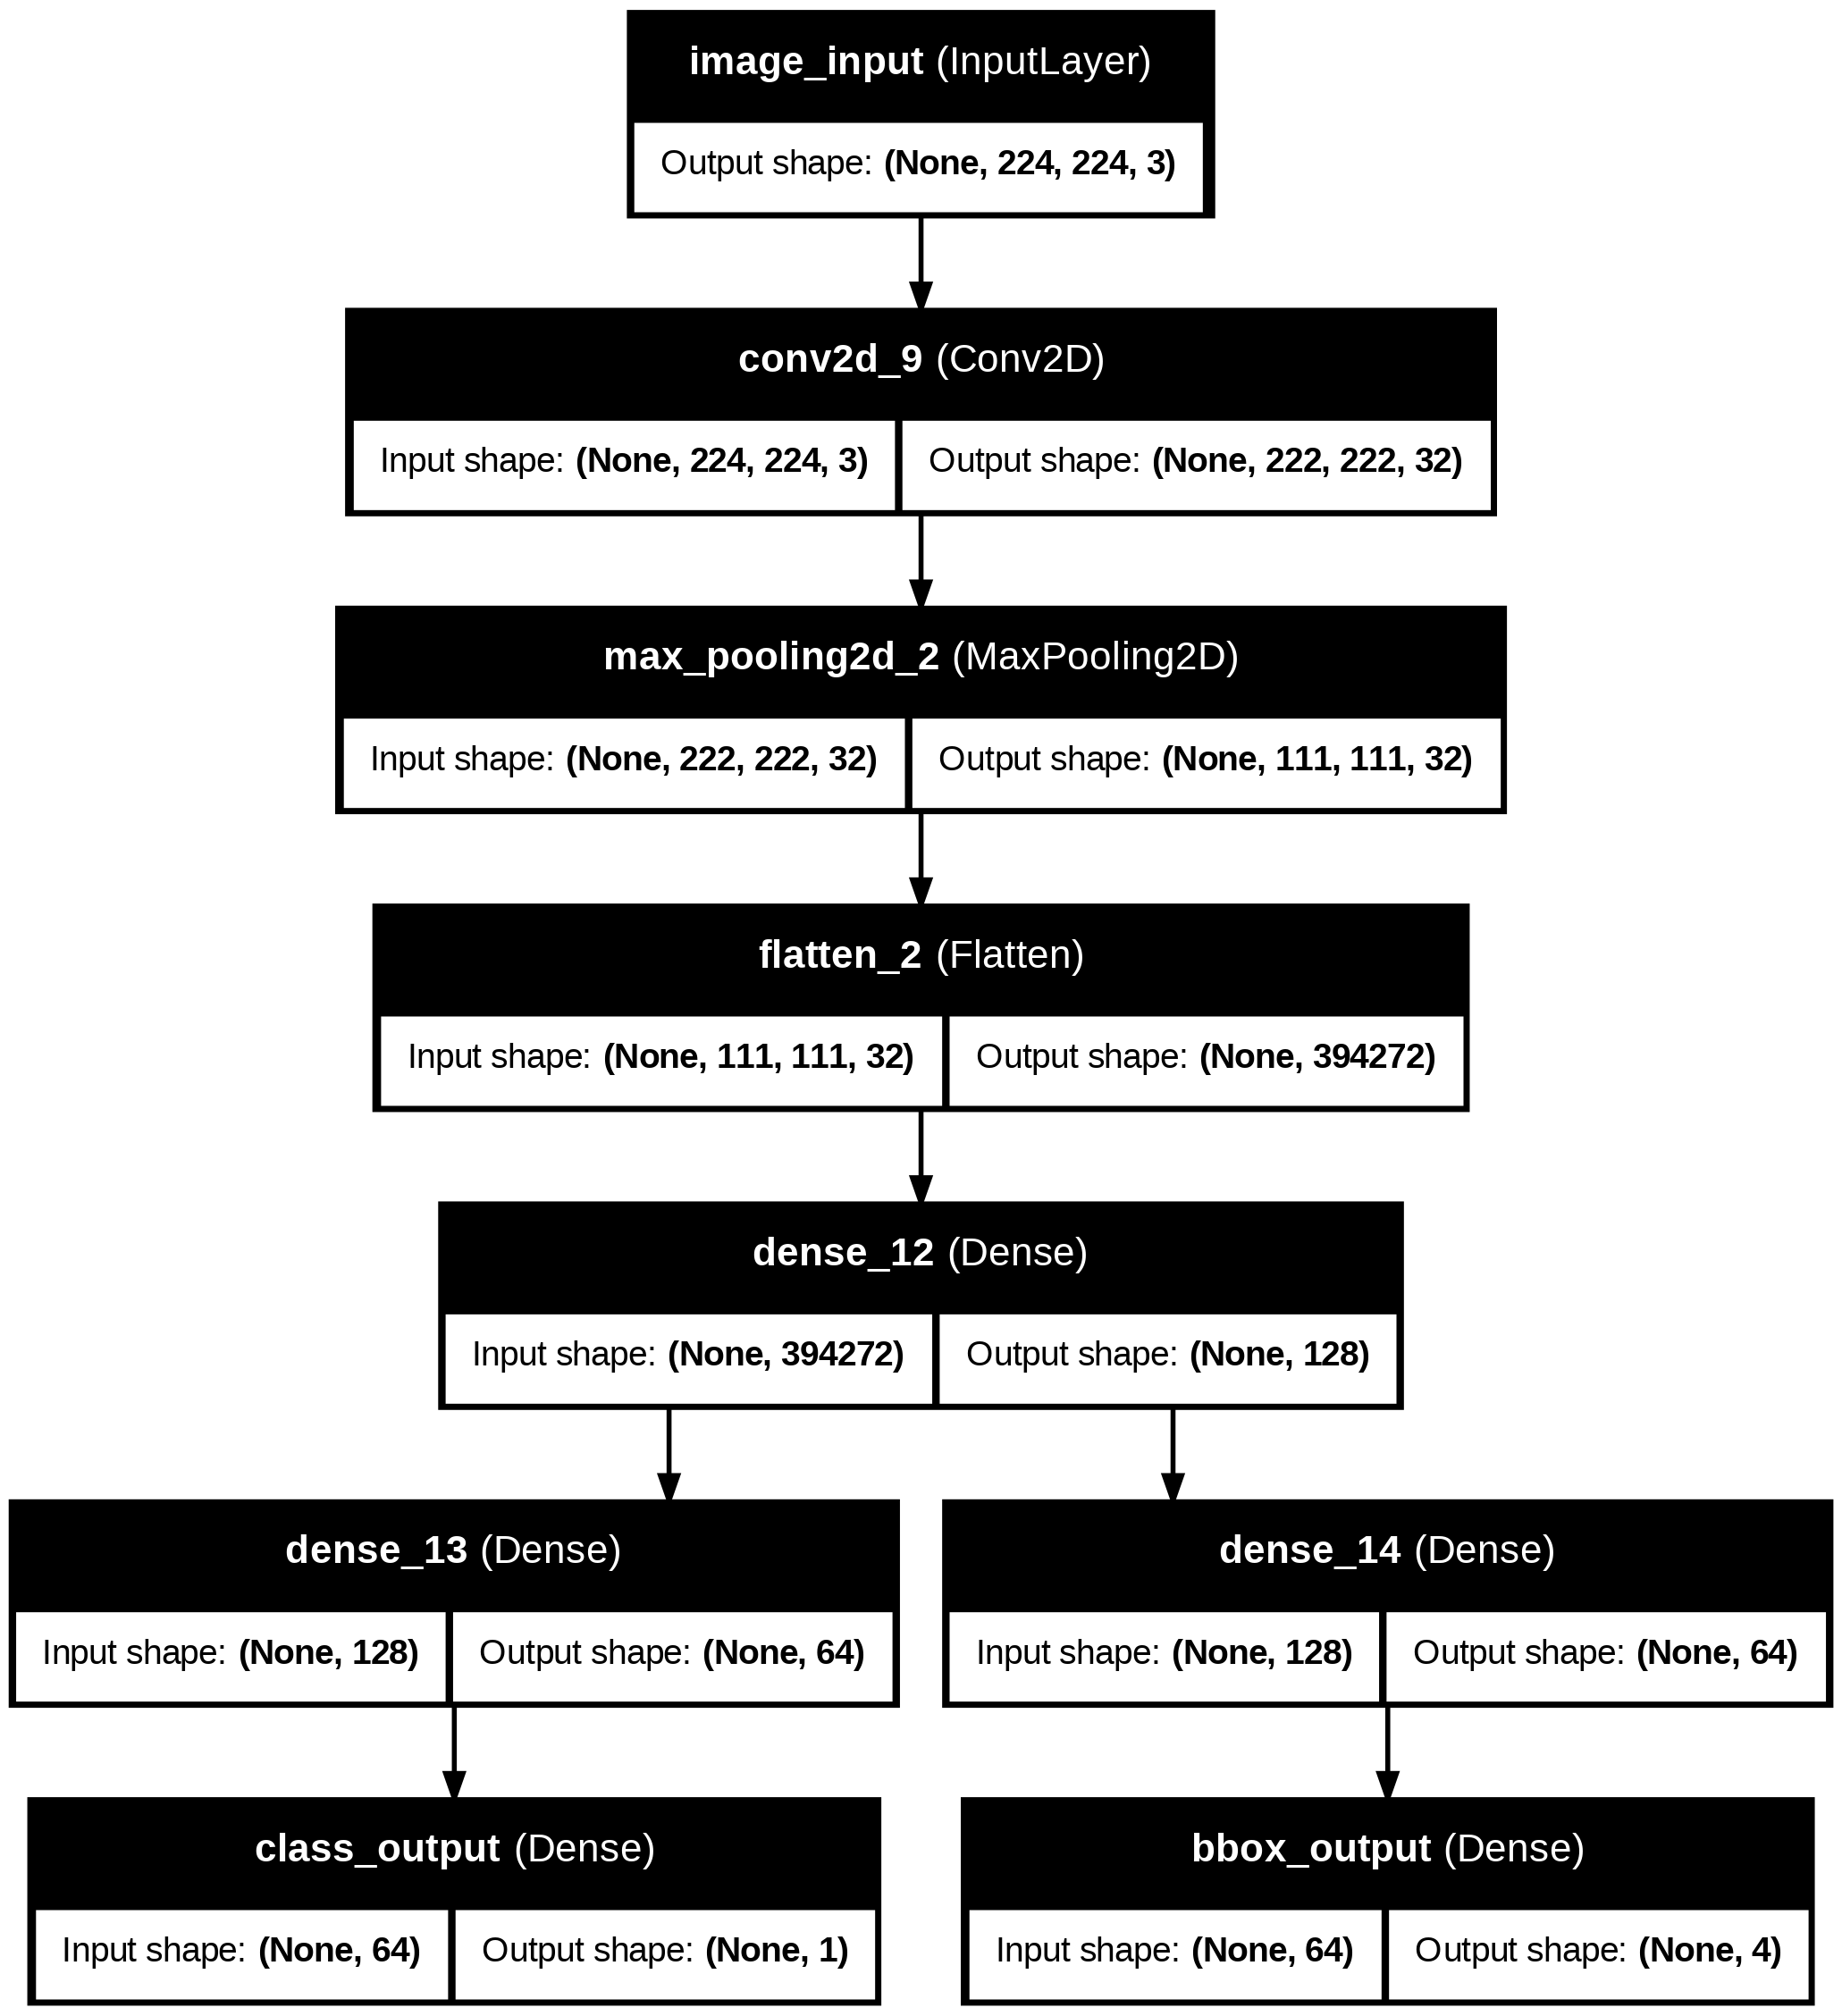

In [15]:
plot_model(model, show_shapes=True, show_layer_names=True)

In [16]:
from tensorflow.keras import Input, Model, layers
import tensorflow as tf


In [17]:
shared_encoder = layers.Dense(64, activation='relu', name = 'shared_encoder')

input_a = Input(shape=(224,224,3), name='image_a')
input_b = Input(shape=(224,224,3), name='image_b')

flat_a = layers.Flatten()(input_a)
flat_b = layers.Flatten()(input_b)

encoded_a = shared_encoder(flat_a)
encoded_b = shared_encoder(flat_b)

distance = layers.Lambda(
    lambda tensors: tf.abs(tensors[0]-tensors[1])
)([encoded_a, encoded_b])

output = layers.Dense(1, activation='sigmoid')(distance)
model = Model(inputs =[input_a, input_b], outputs = output)
model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_a             │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_b             │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 150528)    │          0 │ image_a[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 150528)    │          0 │ image_b[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_encoder      │ (None, 64)        │  9,633,856 │ flatten_3[0][0],  │
│ (Dense)             │                   │            │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64)        │          0 │ shared_encoder[0… │
│                     │                   │            │ shared_encoder[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1)         │         65 │ lambda[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,633,921 (36.75 MB)

 Trainable params: 9,633,921 (36.75 MB)

 Non-trainable params: 0 (0.00 B)

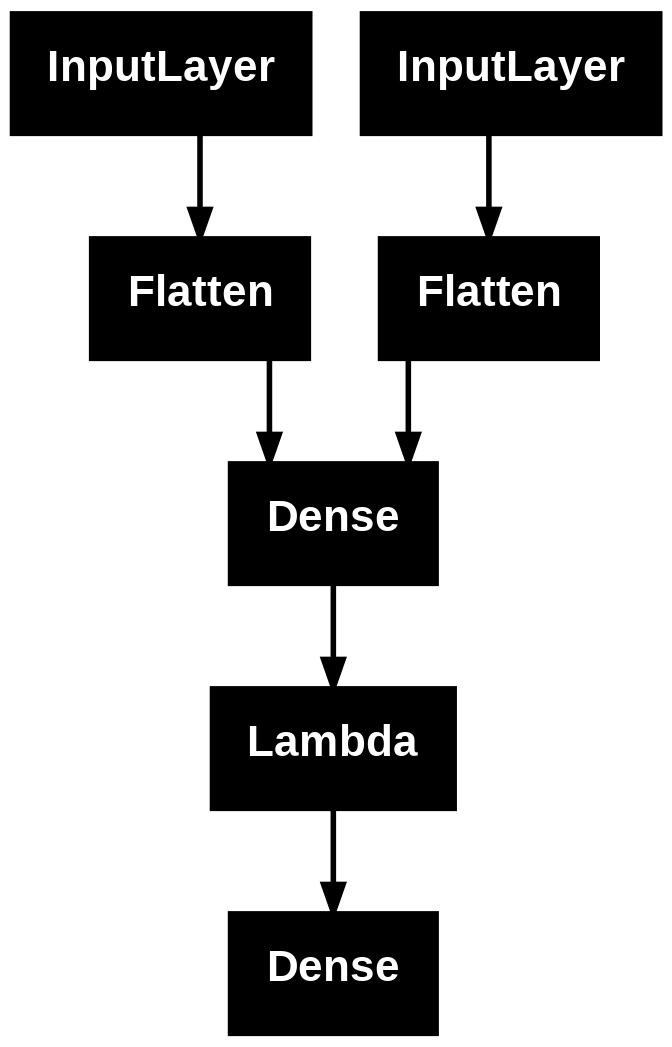

In [18]:
plot_model(model)

In [19]:
from tensorflow.keras import Input, Model, layers
input_a = Input(shape=(224, 224, 3))
input_b = Input(shape=(224, 224, 3)) # Corrected shape here
a = layers.Dense(64, activation='relu')(input_a)
b = layers.Dense(64,activation='relu')(input_b)

# These merging operations now expect compatible shapes
merged_concat = layers.Concatenate()([a,b])
merged_add = layers.Add()([a,b])
merged_average = layers.Average()([a,b])

print(f"Shape after Concatenate: {merged_concat.shape}")
print(f"Shape after Add: {merged_add.shape}")
print(f"Shape after Average: {merged_average.shape}")

Shape after Concatenate: (None, 224, 224, 128)
Shape after Add: (None, 224, 224, 64)
Shape after Average: (None, 224, 224, 64)


In [20]:
def resnet_block(x, filters):
  skip = x
  x = layers.Conv2D(filters, (3,3), padding='same')(x)
  x = layers.BatchNormalization()(x)
  x = layers.ReLU()(x)

  x = layers.Conv2D(filters, (3,3), padding='same')(x)
  x = layers.BatchNormalization()(x)

  x = layers.Add()([x,skip])
  x = layers.ReLU()(x)
  return x

inputs = Input(shape=(64, 64, 3))
x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(inputs)

x = resnet_block(x, 64)   # block 1
x = resnet_block(x, 64)
x = resnet_block(x, 64)

x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)



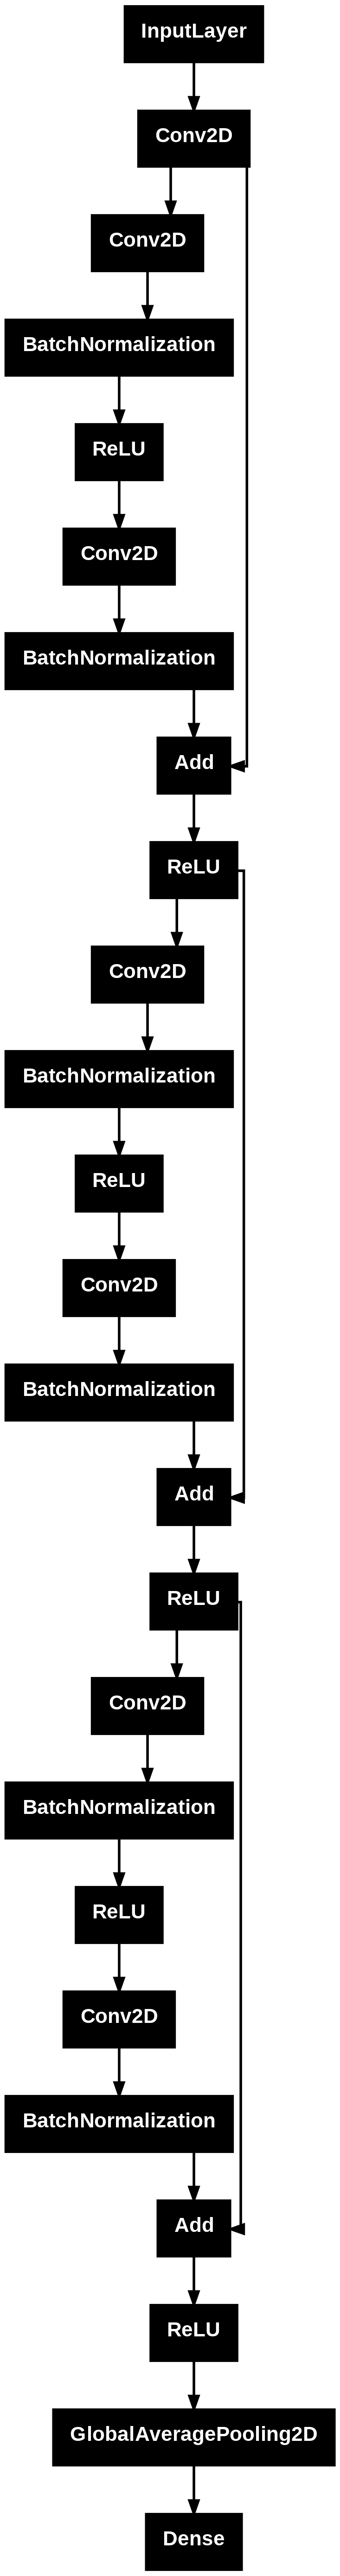

In [22]:
plot_model(model)